In [5]:
import pandas as pd # Manupilação de dados
import numpy as np # Calculos e estatisticas
import matplotlib.pyplot as plt # Graficos

from sklearn.linear_model import LinearRegression # Modelo de regressao linear
from yellowbrick.regressor import ResidualsPlot # Visualizador de residuos

In [7]:
base = pd.read_csv('cars.csv')
base.head()

,Unnamed: 0,speed,dist
0,1,4,2
1,2,4,10
2,3,7,4
3,4,7,22
4,5,8,16


In [8]:
base.shape

(50, 3)

### Remover coluna não utilizada

In [10]:
base = base.drop(['Unnamed: 0'], axis=1) # Remover uma coluna
base.head()

,speed,dist
0,4,2
1,4,10
2,7,4
3,7,22
4,8,16


### Atribuir dados as variaveis X e Y

In [14]:
X = base.iloc[:,1].values # Dados para prever (todos os valores da coluna dist)
Y = base.iloc[:,0].values # Dados para descobrir (todos os valores da coluna speed)

In [16]:
X

array([  2,  10,   4,  22,  16,  10,  18,  26,  34,  17,  28,  14,  20,
        24,  28,  26,  34,  34,  46,  26,  36,  60,  80,  20,  26,  54,
        32,  40,  32,  40,  50,  42,  56,  76,  84,  36,  46,  68,  32,
        48,  52,  56,  64,  66,  54,  70,  92,  93, 120,  85])

In [17]:
Y

array([ 4,  4,  7,  7,  8,  9, 10, 10, 10, 11, 11, 12, 12, 12, 12, 13, 13,
       13, 13, 14, 14, 14, 14, 15, 15, 15, 16, 16, 17, 17, 17, 18, 18, 18,
       18, 19, 19, 19, 20, 20, 20, 20, 20, 22, 23, 24, 24, 24, 24, 25])

## Correlação

In [20]:
correlacao = np.corrcoef(X, Y) # Calcula uma correlação
correlacao

array([[1.       , 0.8068949],
       [0.8068949, 1.       ]])

In [22]:
X = X.reshape(-1,1) # Converte X em uma matriz unidimensional
# Requisito para usar lib sklearn

#### Criar modelo de regressao linear

In [23]:
modelo = LinearRegression()

In [25]:
modelo.fit(X, Y) # Treinamento

LinearRegression()

#### Calcular intersecção

In [26]:
modelo.intercept_ # Calcula a intersecção

np.float64(8.283905641787172)

#### Calcular inclinação

In [27]:
modelo.coef_ # Calcula a inclinação

array([0.16556757])

#### Visualização grafica

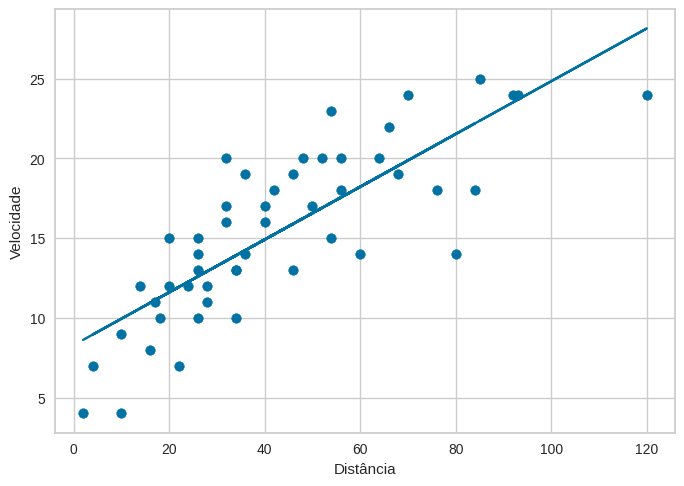

In [31]:
plt.scatter(X,Y) # Pontos no plano grafico
plt.plot(X, modelo.predict(X)) # Linha da regressao
plt.xlabel('Distância')
plt.ylabel('Velocidade')
plt.show()

## Predição

In [32]:
modelo.intercept_ + (modelo.coef_ * 3) # Descobrir a previsão de 3
# Previsao = intersecção + (inclinação * valor para descobrir)

array([8.78060837])

In [33]:
modelo.predict([[3]]) # Função para previsão (fórmula anterior)

array([8.78060837])

## Residuos

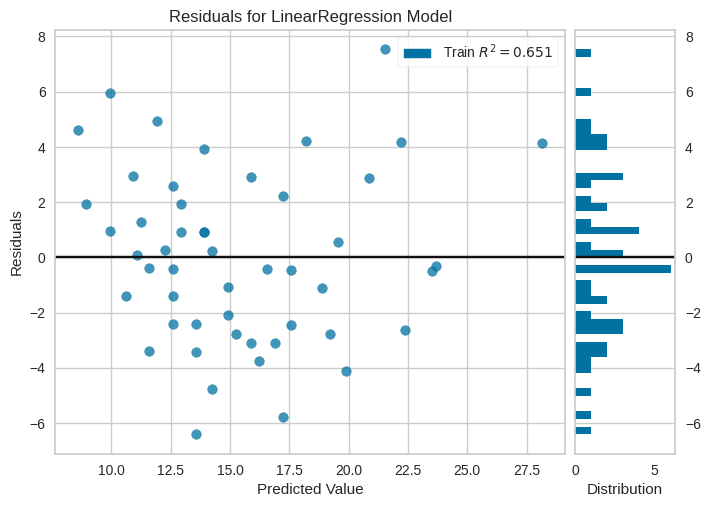

<Axes: title={'center': 'Residuals for LinearRegression Model'}, xlabel='Predicted Value', ylabel='Residuals'>

In [35]:
residuos = ResidualsPlot(modelo)
residuos.fit(X, Y)
residuos.poof()